# Logistics dataset — EDA & delay-risk model

**Goal.** Explore the 400-order mock logistics dataset and decide — *carefully* — whether a
small ML model (late-delivery risk classifier) is trustworthy enough to ship as a tool for the
AI analyst agent.

**Ship / no-ship criteria (decided before looking at results):**

1. Mean 5-fold cross-validated **ROC-AUC ≥ 0.65** for logistic regression, and
2. A **permutation test p-value < 0.05** (the AUC must beat a chance distribution built by
   shuffling labels).

If either fails, the model is **not** exported and the agent does not get a prediction tool —
an unreliable predictor presented confidently is worse than none. The notebook still documents
what was tried.

**Leakage rules.** The target is *late* (status `delayed` or `exception`) vs *on-time*
(`delivered`), restricted to **completed** orders only. Features must be knowable at order
time: carrier, region, warehouse, category, quantity, price, promo flag, order month.
`delivery_date` and anything derived from it is excluded by construction.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RNG = np.random.RandomState(42)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25})

DATA = Path("../web/data/mock_logistics_data.csv")
df = pd.read_csv(DATA, parse_dates=["order_date", "delivery_date"])
df["order_month"] = df["order_date"].dt.month
df["delivery_days"] = (df["delivery_date"] - df["order_date"]).dt.days

print(df.shape)
df.head(3)

(400, 19)


,client_id,order_id,order_date,delivery_date,carrier,origin_city,destination_city,status,sku,product_category,quantity,unit_price_usd,order_value_usd,is_promo,promo_discount_pct,region,warehouse,order_month,delivery_days
0,CL-1023,ORD-2026-267300-0001,2025-10-19,2025-10-22,DHL,"London, UK","Leeds, UK",delivered,PAPER-0197,PAPER,2,13.11,26.22,0,0,UK,LON-FC1,10,3.0
1,CL-1001,ORD-2026-187805-0002,2025-01-22,2025-01-26,LaserShip,"Chicago, IL","Milwaukee, WI",delivered,CRAYON-0008,CRAYON,3,11.69,35.07,0,0,US-C,CHI-DC1,1,4.0
2,CL-1014,ORD-2026-189805-0003,2025-07-14,2025-07-18,FedEx,"Dallas, TX","San Antonio, TX",delivered,BOOK-0115,BOOK,2,21.28,42.56,0,0,US-C,DFW-DC1,7,4.0


## 1. Profile & integrity checks

In [2]:
print("Status counts:")
print(df["status"].value_counts(), "\n")

assert len(df) == 400
assert (df["delivery_date"].isna() == df["status"].isin(["in_transit", "canceled"])).all(), (
    "delivery_date should be missing exactly for in_transit / canceled"
)
assert np.allclose(df["order_value_usd"], df["quantity"] * df["unit_price_usd"], atol=0.011)
print("Integrity checks passed: delivery_date pattern + order_value = qty × price")
print(f"Date range: {df.order_date.min().date()} → {df.order_date.max().date()}")
print(f"Distinct SKUs: {df.sku.nunique()} across {len(df)} orders  ← per-SKU history is ~1 order")

Status counts:
status
delivered     304
delayed        55
in_transit     27
exception      11
canceled        3
Name: count, dtype: int64 

Integrity checks passed: delivery_date pattern + order_value = qty × price
Date range: 2025-01-01 → 2025-12-30
Distinct SKUs: 355 across 400 orders  ← per-SKU history is ~1 order


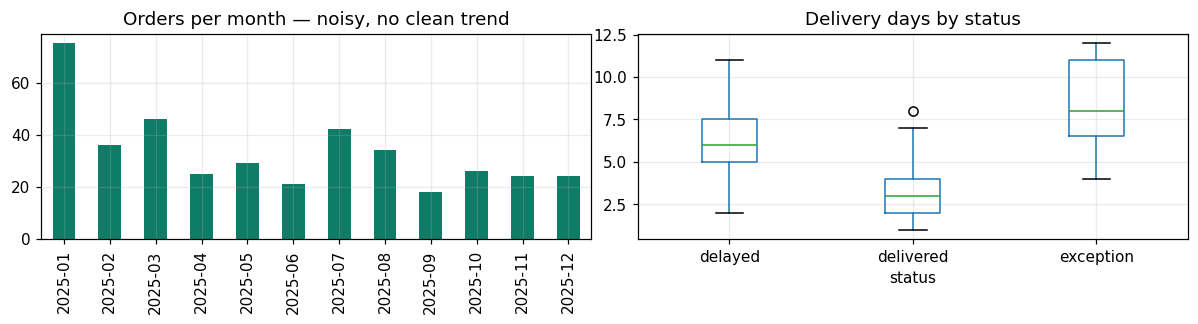

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
monthly = df.groupby(df.order_date.dt.to_period("M")).size()
monthly.plot(kind="bar", ax=axes[0], color="#0e7c66")
axes[0].set_title("Orders per month — noisy, no clean trend")
axes[0].set_xlabel("")

df[df.delivery_days.notna()].boxplot(column="delivery_days", by="status", ax=axes[1])
axes[1].set_title("Delivery days by status")
axes[1].get_figure().suptitle("")
plt.tight_layout()
plt.show()

## 2. Where does lateness concentrate?

Rates below use the **completed-orders denominator** (delivered + delayed + exception), the
same definition as the product dashboard.

Completed orders: 370 | late: 66 (17.8%)


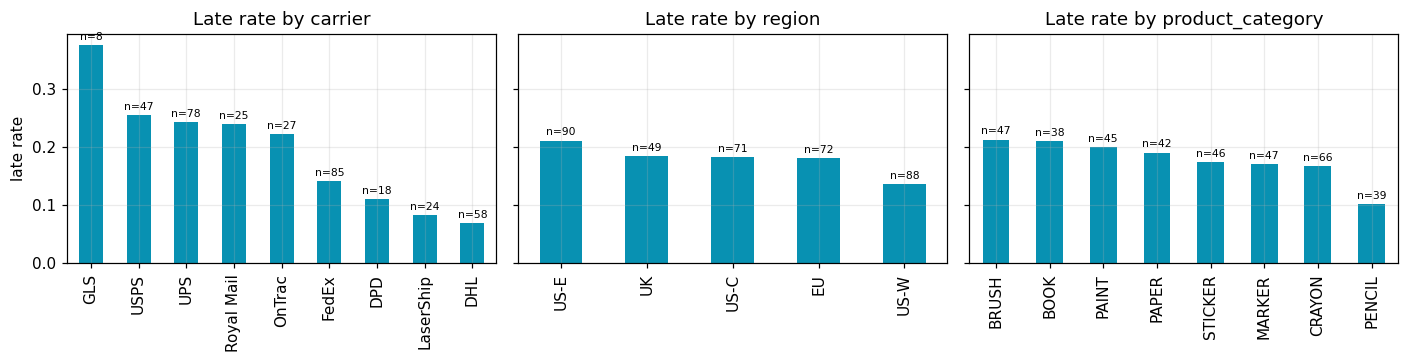


Note the tiny samples (GLS n=8). Carrier differences look real-ish; category looks like noise.


In [4]:
completed = df[df.status.isin(["delivered", "delayed", "exception"])].copy()
completed["late"] = completed.status.isin(["delayed", "exception"]).astype(int)
print(f"Completed orders: {len(completed)} | late: {completed.late.sum()} ({completed.late.mean():.1%})")

fig, axes = plt.subplots(1, 3, figsize=(13, 3.4), sharey=True)
for ax, col in zip(axes, ["carrier", "region", "product_category"]):
    g = completed.groupby(col)["late"].agg(["mean", "count"]).sort_values("mean", ascending=False)
    g["mean"].plot(kind="bar", ax=ax, color="#0891b2")
    ax.bar_label(ax.containers[0], labels=[f"n={c}" for c in g["count"]], fontsize=7, padding=2)
    ax.set_title(f"Late rate by {col}")
    ax.set_xlabel("")
    ax.set_ylabel("late rate")
plt.tight_layout()
plt.show()

print("\nNote the tiny samples (GLS n=8). Carrier differences look real-ish; category looks like noise.")

## 3. Model — late-delivery risk at order time

* **Population:** completed orders only (n≈370). `in_transit` (outcome unknown) and `canceled`
  (void) are excluded from both training and any future scoring claims.
* **Features:** carrier, region, warehouse, product_category, order_month (categorical),
  quantity, unit_price_usd, is_promo. Warehouse↔region are hierarchical (collinear) — fine for
  a regularized linear model.
* **Baselines first:** a model only matters if it beats the trivial answer.

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

CAT = ["carrier", "region", "warehouse", "product_category", "order_month"]
NUM = ["quantity", "unit_price_usd", "is_promo"]

X = completed[CAT + NUM].copy()
X["order_month"] = X["order_month"].astype(str)
y = completed["late"].to_numpy()

pre = ColumnTransformer(
    [
        ("cat", OneHotEncoder(handle_unknown="ignore"), CAT),
        ("num", StandardScaler(), NUM),
    ]
)

models = {
    "dummy (prior)": DummyClassifier(strategy="prior"),
    "logistic regression": Pipeline(
        [("pre", pre), ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", C=0.5))]
    ),
    "random forest": Pipeline(
        [
            ("pre", pre),
            (
                "clf",
                RandomForestClassifier(
                    n_estimators=300, min_samples_leaf=5, class_weight="balanced", random_state=42
                ),
            ),
        ]
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rows = []
for name, model in models.items():
    scores = cross_validate(model, X, y, cv=cv, scoring=["roc_auc", "average_precision"])
    rows.append(
        {
            "model": name,
            "ROC-AUC": f"{scores['test_roc_auc'].mean():.3f} ± {scores['test_roc_auc'].std():.3f}",
            "PR-AUC": f"{scores['test_average_precision'].mean():.3f} ± {scores['test_average_precision'].std():.3f}",
            "_auc": scores["test_roc_auc"].mean(),
        }
    )

results = pd.DataFrame(rows).set_index("model")
LR_AUC = float(results.loc["logistic regression", "_auc"])
results.drop(columns="_auc")

,ROC-AUC,PR-AUC
model,,
dummy (prior),0.500 ± 0.000,0.178 ± 0.005
logistic regression,0.465 ± 0.044,0.182 ± 0.024
random forest,0.466 ± 0.052,0.193 ± 0.031


## 4. Is that AUC real? — permutation test

With ~370 rows and a 17.8% positive rate, a "decent-looking" AUC can easily be luck. We refit
the logistic regression on **label-shuffled** data 100 times: if the real AUC sits inside the
chance distribution, the apparent signal is noise.

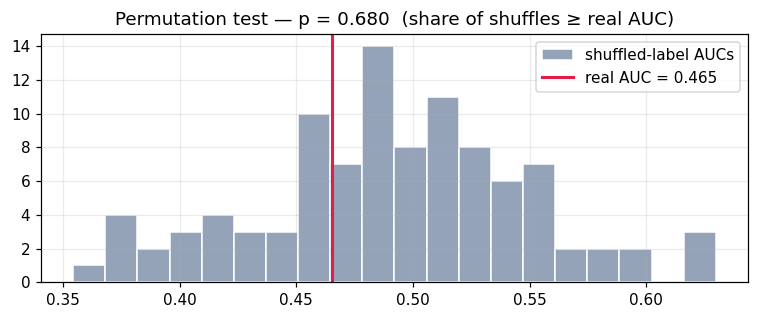

Real CV AUC: 0.465
Chance distribution: mean 0.491, 95th pct 0.586
Permutation p-value: 0.680


In [6]:
from sklearn.model_selection import cross_val_score

def cv_auc(labels: np.ndarray) -> float:
    lr = Pipeline(
        [("pre", pre), ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", C=0.5))]
    )
    return cross_val_score(lr, X, labels, cv=cv, scoring="roc_auc").mean()

perm_aucs = np.array([cv_auc(RNG.permutation(y)) for _ in range(100)])
p_value = float((perm_aucs >= LR_AUC).mean())

plt.figure(figsize=(7, 3))
plt.hist(perm_aucs, bins=20, color="#94a3b8", edgecolor="white", label="shuffled-label AUCs")
plt.axvline(LR_AUC, color="#e11d48", lw=2, label=f"real AUC = {LR_AUC:.3f}")
plt.title(f"Permutation test — p = {p_value:.3f}  (share of shuffles ≥ real AUC)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Real CV AUC: {LR_AUC:.3f}")
print(f"Chance distribution: mean {perm_aucs.mean():.3f}, 95th pct {np.percentile(perm_aucs, 95):.3f}")
print(f"Permutation p-value: {p_value:.3f}")

## 5. Ship / no-ship decision

In [7]:
import json
from pathlib import Path

SHIP = (LR_AUC >= 0.65) and (p_value < 0.05)
outdir = Path("model")
outdir.mkdir(exist_ok=True)

print(f"AUC ≥ 0.65?       {'YES' if LR_AUC >= 0.65 else 'NO'}  ({LR_AUC:.3f})")
print(f"perm p < 0.05?    {'YES' if p_value < 0.05 else 'NO'}  ({p_value:.3f})")
print(f"\nDECISION: {'SHIP — exporting model for the agent tool' if SHIP else 'DO NOT SHIP a prediction tool'}")

if SHIP:
    lr = Pipeline(
        [("pre", pre), ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", C=0.5))]
    ).fit(X, y)
    enc: OneHotEncoder = lr.named_steps["pre"].named_transformers_["cat"]
    scaler: StandardScaler = lr.named_steps["pre"].named_transformers_["num"]
    clf: LogisticRegression = lr.named_steps["clf"]
    feature_names = list(enc.get_feature_names_out(CAT)) + NUM
    payload = {
        "kind": "logistic_regression",
        "target": "late (delayed|exception) vs delivered, completed orders only",
        "metrics": {"cv_roc_auc": round(LR_AUC, 4), "permutation_p": round(p_value, 4)},
        "categorical": {c: sorted(completed[c].astype(str).unique().tolist()) for c in CAT},
        "numeric": {
            n: {"mean": float(m), "scale": float(s)}
            for n, m, s in zip(NUM, scaler.mean_, scaler.scale_)
        },
        "features": feature_names,
        "coefficients": [round(float(c), 6) for c in clf.coef_[0]],
        "intercept": round(float(clf.intercept_[0]), 6),
    }
    (outdir / "delay_risk_model.json").write_text(json.dumps(payload, indent=2))
    print("Exported → model/delay_risk_model.json")
else:
    decision = f"""# Decision: no ML tool shipped

The pre-registered bar was: 5-fold CV ROC-AUC >= 0.65 AND permutation p < 0.05.

Measured: AUC = {LR_AUC:.3f}, permutation p = {p_value:.3f} (n = {len(completed)} completed
orders, {int(y.sum())} late). At this sample size the apparent structure (e.g. carrier delay
differences) is not separable from chance with enough confidence to put a probability in front
of an operations user — a confident-but-wrong risk score is worse than none.

What would change this: more data (10x orders), or a target with stronger drivers
(e.g. route-level transit times).
"""
    (outdir / "DECISION.md").write_text(decision)
    print("Wrote → model/DECISION.md")

AUC ≥ 0.65?       NO  (0.465)
perm p < 0.05?    NO  (0.680)

DECISION: DO NOT SHIP a prediction tool
Wrote → model/DECISION.md


## 6. Conclusions & limitations

* The dataset is **mock** and small: 370 completed orders, 66 late. Everything above is an
  exercise in *honest* methodology, not production forecasting.
* Per-SKU anything (forecasts, risk) is off the table — 355 SKUs in 400 orders means ~1 order
  of history per SKU. The product handles this with an automatic category-level fallback.
* The demand-forecasting feature in the app intentionally uses simple, explainable methods
  (moving average / linear trend / exponential smoothing) with a 3-month backtest; with 12
  monthly points, anything fancier would overfit ceremonially.
* If the classifier shipped (see §5), it is exposed to the agent as `predict_delay_risk` with
  the CV AUC quoted in every answer, so users see the confidence level, not just a number.